# Data Analysis 

In [263]:
## Dependencies
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import boxcox
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss

### 1. Acquiring datasets

In [264]:
# NVIDIA dataset:
nvidia = yf.download("NVDA", start="2020-01-01", end="2026-07-01")
nvidia.columns = nvidia.columns.get_level_values(0)
nvidia.columns.name = None # removing title of column names.
nvidia.reset_index(inplace=True) # resetting index to have date as a column.

nvidia["Date"] = pd.to_datetime(nvidia["Date"]) # date column as Date.
nvidia.head(5)

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2020-01-02,5.963804,5.963804,5.884506,5.934968,237536000
1,2020-01-03,5.868347,5.912098,5.819376,5.844234,205384000
2,2020-01-06,5.892957,5.898177,5.749026,5.775128,262636000
3,2020-01-07,5.964302,6.010041,5.876302,5.921296,314856000
4,2020-01-08,5.975487,6.016752,5.920052,5.960074,277108000


In [265]:
# Semiconductor billing dataset:
sia = pd.read_csv('americas_semiconductor_billings.csv') # one value per month; low granularity compared to nvidia dataset.
sia["Date"] = pd.to_datetime(sia["Date"])
sia.head(5)

/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_12131/2856192465.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sia["Date"] = pd.to_datetime(sia["Date"])


,Date,Value
0,2026-05-31,46.42M
1,2026-04-30,41.53M
2,2026-03-31,40.60M
3,2026-02-28,36.20M
4,2026-01-31,24.63M


In [266]:
# Merging:
merged = pd.merge(
    nvidia,
    sia[["Date", "Value"]],
    on="Date",
    how="left" # keep the all dates form nvidia set.
)

merged["Value"] = merged["Value"].fillna("")

## Output:
display(merged[merged["Value"] != ""].head(5)) # value column filled only at end of month.
display(merged.head(10))

,Date,Close,High,Low,Open,Volume,Value
607,2022-05-31,18.616375,19.142802,18.295334,18.923456,664100000,12.61M
628,2022-06-30,15.117032,15.523902,14.820854,15.318472,686070000,12.10M
671,2022-08-31,15.052211,15.496976,14.917584,15.341408,573710000,11.52M
692,2022-09-30,12.108989,12.601768,12.045147,12.057117,565638000,13.77M
713,2022-10-31,13.463632,13.803789,13.264126,13.743937,486341000,11.69M


,Date,Close,High,Low,Open,Volume,Value
0,2020-01-02,5.963804,5.963804,5.884506,5.934968,237536000,
1,2020-01-03,5.868347,5.912098,5.819376,5.844234,205384000,
2,2020-01-06,5.892957,5.898177,5.749026,5.775128,262636000,
3,2020-01-07,5.964302,6.010041,5.876302,5.921296,314856000,
4,2020-01-08,5.975487,6.016752,5.920052,5.960074,277108000,
5,2020-01-09,6.041113,6.113452,5.987419,6.061746,255112000,
6,2020-01-10,6.073430,6.178581,6.059260,6.148254,316296000,
7,2020-01-13,6.263846,6.288953,6.133836,6.156457,319840000,
8,2020-01-14,6.147011,6.246445,6.133836,6.221089,359088000,
9,2020-01-15,6.104503,6.182061,6.078650,6.159689,263104000,


### 2. Data Inspection

In [267]:
# Inspecting and cleaning time series data

## Date as index in both datasets:
sia.set_index("Date", inplace=True)
nvidia.set_index("Date", inplace=True)


In [268]:
## Duplicates
print(sia.duplicated().sum()) # 1 potential duplicate in sia.
print(nvidia.duplicated().sum())

1
0


In [269]:
sia[sia["Value"].duplicated(keep=False)] # duplicate is just the value in different months; duplicate should NOT be removed.

,Value
Date,
2025-03-31,20.71M
2024-11-30,20.71M


In [270]:
## Null
nvidia.isnull().sum()
sia.isnull().sum()
# NONE

Value    0
dtype: int64

In [271]:
## Differences in time stamps (now, index)
nvidia.index.to_series().diff().value_counts()

Date
1 days    1276
3 days     291
4 days      48
2 days      15
Name: count, dtype: int64

In [272]:
## month-end data from nividia:
nvidia_monthly = nvidia.resample("ME").last()
nvidia_monthly.head(5)

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-31,5.877295,6.076660,5.835532,6.064728,370420000
2020-02-29,6.717552,6.777000,6.014133,6.030798,1133252000
2020-03-31,6.556622,6.850128,6.411113,6.646166,949960000
2020-04-30,7.269989,7.423706,7.256060,7.369731,375916000
2020-05-31,8.830542,8.830542,8.442020,8.511168,745256000


### 2a. Feature Engineering

In [273]:
# turning Value from string to numeric:
sia["Value_num"] = sia["Value"].str.replace("M", "", regex=False)

sia["Value_num"] = pd.to_numeric(sia["Value_num"])

In [274]:
# Lagging by one day:
nvidia["Close_lag1"] = nvidia["Close"].shift(1)
nvidia["Close_lag2"] = nvidia["Close"].shift(2)

sia["Value_lag1"] = sia["Value_num"].shift(1)
sia["Value_lag2"] = sia["Value_num"].shift(2)

In [275]:
# Rolling statistics: helps capture short-term trends
## Rolling averages, e.g.: how mean sales change over a rolling 5-day period?

nvidia["rolling_mean_3"] = nvidia["Close"].rolling(3).mean()
nvidia["rolling_sd_3"] = nvidia["Close"].rolling(3).std()

sia["rolling_mean_3"] = sia["Value_num"].rolling(3).mean()
sia["rolling_sd_3"] = sia["Value_num"].rolling(3).std()

In [276]:
# Expanding Window features:
## For 'cumulative' information
nvidia["expanding_mean"] = nvidia["Close"].expanding().mean() # cumulative/'expanding' mean per row, i.e. mean of row 1, mean of rows 1 and 2, and so on.
sia["expanding_mean"] = sia["Value_num"].expanding().mean()

In [277]:
# % change feature:
nvidia["return"] = nvidia["Close"].pct_change() # pct(%) change in Close value from previous row (lag of 1 is default)
sia["Value_growth"] = sia["Value_num"].pct_change()

In [278]:
# Date component extraction:
nvidia["Year"] = nvidia.index.year
nvidia["Month"] = nvidia.index.month

sia["Year"] = sia.index.year
sia["Month"] = sia.index.month

### 2b. Merging Multi-Source Data

In [279]:
# Merging datasets:

## a common column that captures the year and month (Y-m), by capturing the monthly frequency, i.e. to_period("M")
nvidia["YM"] = nvidia.index.to_period("M")
sia["YM"] = sia.index.to_period("M")

final = pd.merge(nvidia.reset_index(), sia.reset_index(), # turns index (or Date) into a dataset column => required for merging
                 on="YM",
                 how="inner") # keeps the months that appear in both datasets in 'final'

### 3. Transformations

In [280]:
# removing duplicates in both datasets:
nvidia.duplicated(subset="YM").sum() # 1553 of nvidia
sia.duplicated(subset="YM").sum()

nvidia = nvidia.drop_duplicates(subset="YM")
sia = sia.drop_duplicates(subset="YM")

In [281]:
### double check:
nvidia["YM"][~nvidia.duplicated(subset="YM")].head() # ~ negates the mask => the first (non-duplicate) row of each month

Date
2020-01-02    2020-01
2020-02-03    2020-02
2020-03-02    2020-03
2020-04-01    2020-04
2020-05-01    2020-05
Name: YM, dtype: period[M]

In [282]:
# Merging for new final df:
final = pd.merge(nvidia.reset_index(),
                 sia.reset_index(),
                 on="YM",
                 how="inner")

In [283]:
# Transformations: Log, Box-Cox, Differencing
## AIM: To NORMALISE the distribution of data
# Reshape/rescale the data so it meets model assumptions: stabilise variance (e.g. log),
# put features on a comparable scale (normalise/standardise), and remove trend/seasonality
# to make the series stationary => cleaner signal and better-behaved, more accurate models.

########################
# 1. Log Transformation:
final["log_Close"] = np.log(final["Close"])
final["log_Value"] = np.log(final["Value_num"])

# 2. Box-Cox Transformation
## lam (lambda) = the power boxcox picks to best normalise the data (0=log, 0.5=sqrt, 1=no transform).
## boxcox only works on POSITIVE values.
final["boxcox_Close"], lam = boxcox(final["Close"])

# 3. First Differencing
## each value minus the previous one (value[t] - value[t-1]) => removes trend to make the series stationary.
final["diff_Close"] = final["Close"].diff()
final["diff_Value"] = final["Value_num"].diff()

# 4. Seasonal Differencing
## each value minus the one m periods earlier (value[t] - value[t-m]) => removes a repeating seasonal cycle.
final["seasonal_diff_Close"] = final["Close"].diff(12) # yearly difference

## FINAL: drop na rows, for complete dataset
final = final.dropna()

### 4. Forecast Evaluation Metrics

#### Useful for picking up on Anomalies = unexpected drops or spikes in data.

In [284]:
# MAE = Mean Absolute Error; simple metric.
# RMSE = Root Mean of Squared Errors; Punishes big errors.
# MAPE = Mean Absolute Percentage Error; error as a % of actuals, so scale-independent, i.e.: a %, not data units => comparable across differently-sized series.

## Feature Engineering

### 5. Visualizing Trends & Patterns

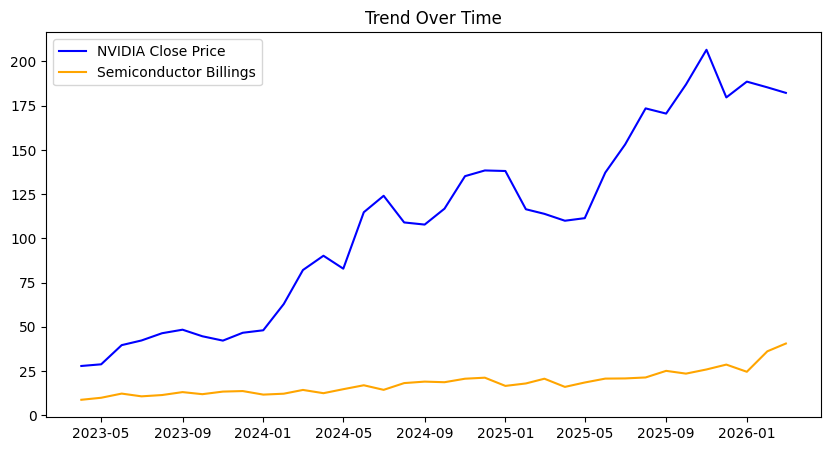

In [285]:
# time series split
## Line Plot:
final['YM'] = final['YM'].dt.to_timestamp() # Y-M is now continuous, so can be plotted on x-axis as a time series.

## OUTPUT:
plt.figure(figsize=(10,5))
plt.plot(final['YM'], final['Close'], label='NVIDIA Close Price', color='blue')
plt.plot(final['YM'], final['Value_num'], label='Semiconductor Billings', color='orange')
plt.legend()
plt.title("Trend Over Time")
plt.show()

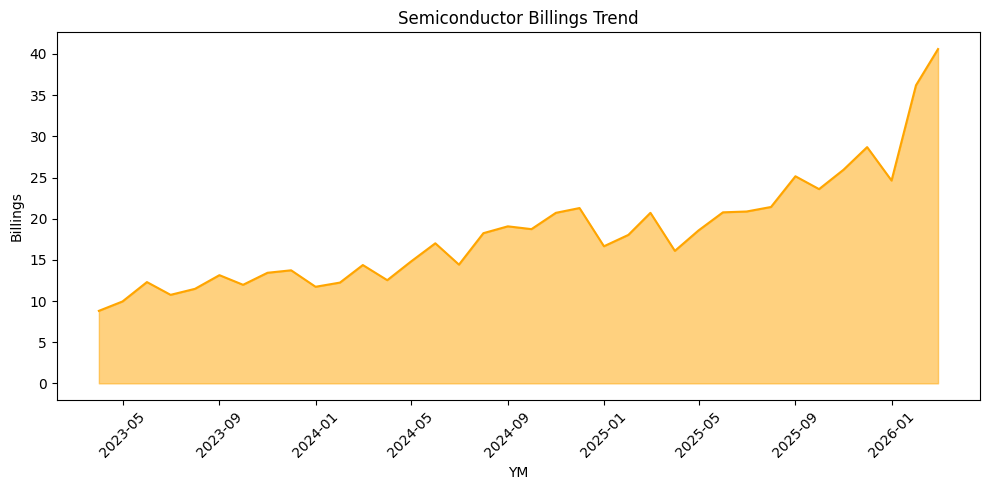

In [286]:
## Billings Trend:
plt.figure(figsize=(10,5))
plt.fill_between(final['YM'], final['Value_num'], color='orange', alpha=0.5)
plt.plot(final['YM'], final['Value_num'], label='Semiconductor Billings', color='orange')

plt.title("Semiconductor Billings Trend")
plt.xlabel("YM")
plt.ylabel("Billings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

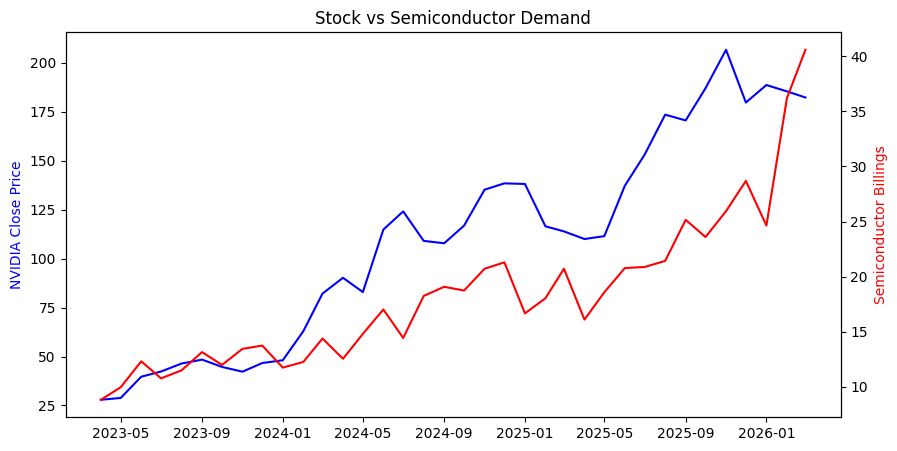

In [287]:
## Dual axis:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(final['YM'], final['Close'], color='blue')
ax1.set_ylabel('NVIDIA Close Price', color='blue')

ax2 = ax1.twinx() # second y-axis sharing the same x-axis => plots billings (different scale) alongside Close.
ax2.plot(final['YM'], final['Value_num'], color='red')
ax2.set_ylabel('Semiconductor Billings', color='red')

plt.title("Stock vs Semiconductor Demand")
plt.show()

# Allows for between-parameter (y-axis) comparisons.

### 5a. Seasonal Decomposition = breaking into smaller meaningful chunks

In [288]:
# Components: Trend (long-term direction), Seasonality (repeating patterns), and Residuals (random noise).

final['Date_x'] = pd.to_datetime(final['Date_x']) # ensures Date is in datetime format for plotting.
final = final.sort_values('Date_x') # sorts the dataframe by date in ascending order.

final.set_index('Date_x', inplace=True) # date is now index.


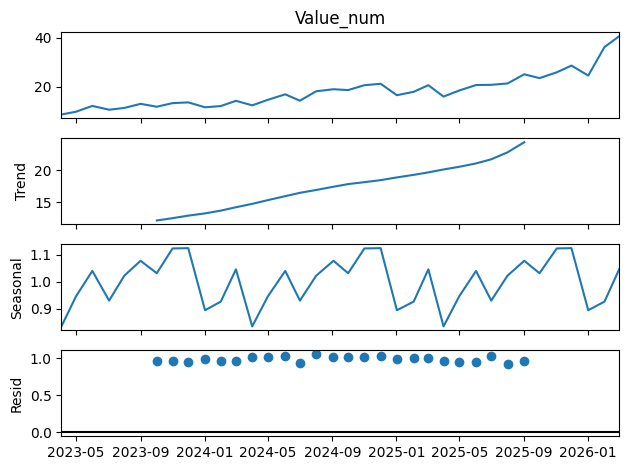

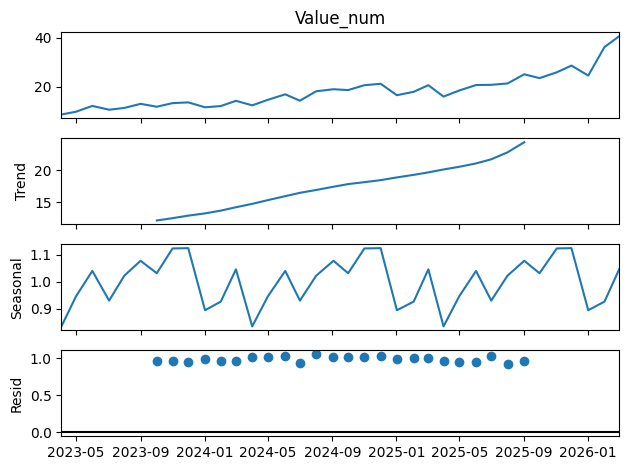

In [289]:
# Decomposition
## for the SIA data of Value_num, which is monthly and has a clear seasonal pattern.

sia_result = seasonal_decompose( # splits the series into trend + seasonal + residual components
    final['Value_num'], # the series being decomposed (semiconductor billings)
    model = 'multiplicative', # components multiply (trend * seasonal * resid); used when seasonal swings grow with the trend
    period=12 # length of one seasonal cycle: 12 => yearly pattern in monthly data
)

sia_result.plot() # plots the original series + the 3 extracted components stacked


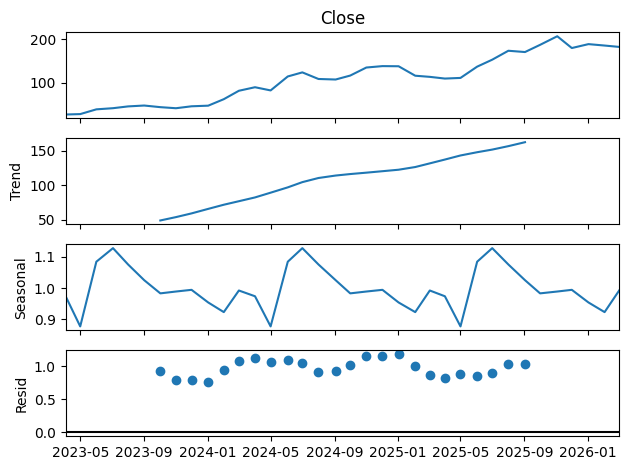

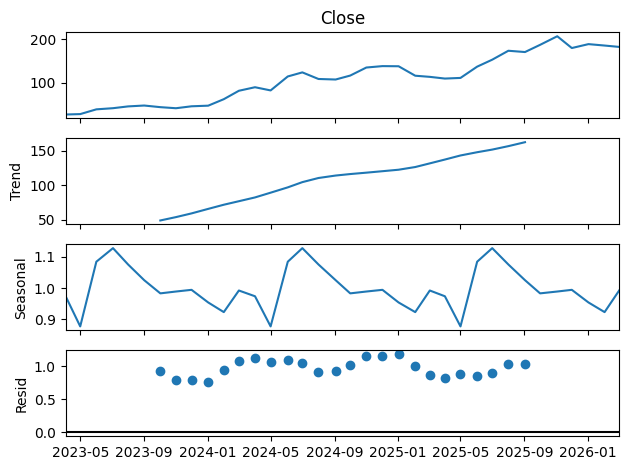

In [290]:
## for NVIDIA stok data:
nvda_result = seasonal_decompose(
    final['Close'],
    model='multiplicative',
    period=12
)

nvda_result.plot()

**Why `multiplicative` (not `additive`)?**

- **Additive**: $y_t = T_t + S_t + R_t$ — seasonal swings stay a **constant size** over time.
- **Multiplicative**: $y_t = T_t \times S_t \times R_t$ — seasonal swings **scale with the level** of the series.

(where $T_t$ = trend, $S_t$ = seasonal, $R_t$ = residual)

Billings trend upward and their seasonal swings grow with that level => multiplicative fits better.


**The three components:**

- **Trend ($T_t$)** — the long-term direction of the series (overall rise or fall), stripped of short-term wiggles.
- **Seasonal ($S_t$)** — the repeating cycle of fixed length (here the yearly pattern from `period=12`).
- **Residual ($R_t$)** — whatever is left after removing trend and seasonal: the irregular "noise" the model can't explain.

The aim is **not** to minimise the residual by choice — it's a <u>diagnostic</u>, not a knob. A good decomposition leaves a residual that is small and **patternless** (random, hovering around 1 for multiplicative). Leftover structure in the residual means the trend/seasonal fit missed something.


### Best technique for decomposition: 
#### STL Decomposition: Seasonal-Trend decomposition using LOESS (STL)

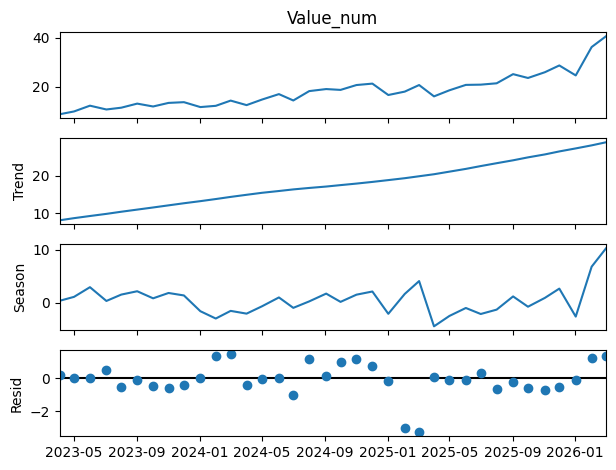

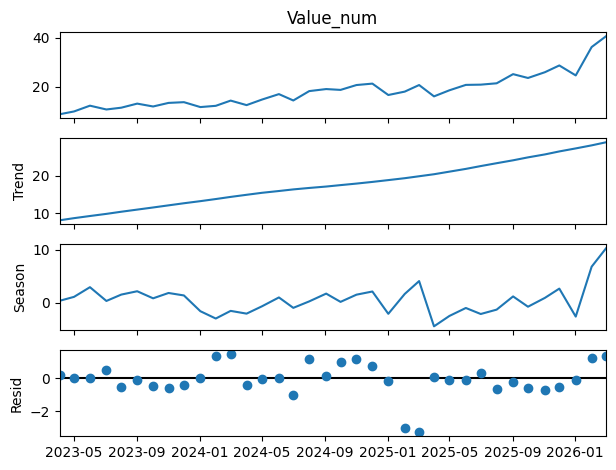

In [291]:
# STL Decomposition: Seasonal-Trend decomposition using LOESS (STL)
## Splits the series into trend + seasonal + residual (like seasonal_decompose),
## but uses LOESS smoothing => the seasonal shape can slowly change over time and it handles outliers better.

## >Therefore, seasonality does not have to be a strictly repeating pattern, and can change over time (e.g. due to changing market conditions).

stl_sia = STL(final['Value_num'], period=12).fit()
stl_sia.plot()

### 5b. Stationarity Testing - ADF & KPSS

##### Stationarity:
 A series is STATIONARY if its statistical properties stay constant over time:
 - constant mean (no trend)
 - constant variance (spread doesn't grow/shrink)
 - autocorrelation depends only on the lag (gap between points), not on when you look.

 **Why it matters:** most forecasting models (e.g. ARIMA) ASSUME stationarity => a stable pattern they can learn and project forward. Trend/seasonality break this, which is why we transform/difference the data first.

 ADF & KPSS are hypothesis tests that formally check whether the series is stationary.

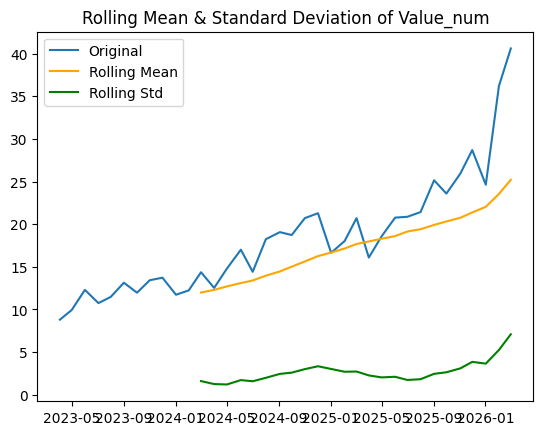

In [292]:
# Visualize:

rolling_mean = final['Value_num'].rolling(window=12).mean() # 12-month rolling mean
rolling_std = final['Value_num'].rolling(window=12).std() # 12-month rolling standard deviation

plt.plot(final['Value_num'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean', color='orange')
plt.plot(rolling_std, label='Rolling Std', color='green')
plt.legend()
plt.title('Rolling Mean & Standard Deviation of Value_num')
plt.show()

# Mean and Std are increasing over time = No stationarity.

In [293]:
# Statistical test for stationarity: Augmented Dickey-Fuller (ADF) test

adf_result = adfuller(final['Value_num']) # returns a tuple of test statistic, p-value, and critical values

print(f"ADF statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.3f}")
if adf_result[1] < 0.05:
    print("The series is stationary (reject H0)")
else:
    print(f"The series is non-stationary (p = {adf_result[1]:.3f})")


ADF statistic: 1.209
p-value: 0.996
The series is non-stationary (p = 0.996)


/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_12131/866624036.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(final['Value_num']) # returns a tuple of test statistic, p-value, and critical values


In [294]:
# Statistical test for stationarity: KPSS test
## NOTE: KPSS reverses the hypotheses vs ADF => here H0 = STATIONARY.
## So p < 0.05 means REJECT stationarity (non-stationary); p >= 0.05 means stationary.

kpss_result = kpss(final['Value_num'], regression='c', nlags='auto') # returns (statistic, p-value, lags, critical values)

print(f"KPSS statistic: {kpss_result[0]:.3f}")
print(f"p-value: {kpss_result[1]:.3f}")
if kpss_result[1] < 0.05:
    print(f"The series is non-stationary (reject H0, p = {kpss_result[1]:.3f})")
else:
    print(f"The series is stationary (p = {kpss_result[1]:.3f})")


KPSS statistic: 0.926
p-value: 0.010
The series is non-stationary (reject H0, p = 0.010)


/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_12131/2310657812.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(final['Value_num'], regression='c', nlags='auto') # returns (statistic, p-value, lags, critical values)
/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_12131/2310657812.py:5: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_result = kpss(final['Value_num'], regression='c', nlags='auto') # returns (statistic, p-value, lags, critical values)


**The test equations**

**ADF** — regression: $\;\Delta y_t = \alpha + \beta t + \gamma\, y_{t-1} + \sum_{i=1}^{p} \delta_i\, \Delta y_{t-i} + \varepsilon_t\;$; statistic $= \hat{\gamma} / \text{SE}(\hat{\gamma})$.
- H0: $\gamma = 0$ (non-stationary) vs H1: $\gamma < 0$ (stationary). Small p => stationary.
- *Intuition:* 
$\gamma = 0$ => the change doesn't depend on $y_{t-1}$, so the series has no pull back to a mean => a **random walk (non-stationary)**. 
$\gamma < 0$ => high values get pushed down / low values up => **mean reversion (stationary)**. So it's a *negative* relationship, not just any, that means stationary.

**KPSS** — statistic: $\;\text{KPSS} = \dfrac{1}{T^2} \sum_{t=1}^{T} S_t^{\,2} / \hat{\sigma}^2\;$, where $S_t = \sum_{i=1}^{t} \hat{\varepsilon}_i$ (cumulative residuals), $\hat{\sigma}^2$ = long-run variance.
- H0: stationary vs H1: non-stationary (**reverse of ADF**). Small p => non-stationary.


In [295]:
# Returns = change in close between y(t) and y(t-1).
final['Returns'] = final['Close'].pct_change() # pct(%) change in Close value from previous row (lag of 1 is default)

final = final.dropna()

adf_res = adfuller(final['Returns'])

print(f"ADF statistic: {adf_res[0]:.3f}")
print(f"p-value: {adf_res[1]:.3f}")
if adf_res[1] < 0.05:
    print("The series is stationary (reject H0)")
else:
    print(f"The series is non-stationary (p = {adf_res[1]:.3f})")


ADF statistic: -4.967
p-value: 0.000
The series is stationary (reject H0)


/var/folders/7n/53byrv256zx1_3t79kv_fj880000gn/T/ipykernel_12131/1559166795.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_res = adfuller(final['Returns'])


In [ ]:
# If data is 'Non-Stationary', transformations needed.

## Differencing:
final['Value_diff'] = final['Value_num'].diff() # first differencing to remove trend and make series stationary
final = final.dropna()

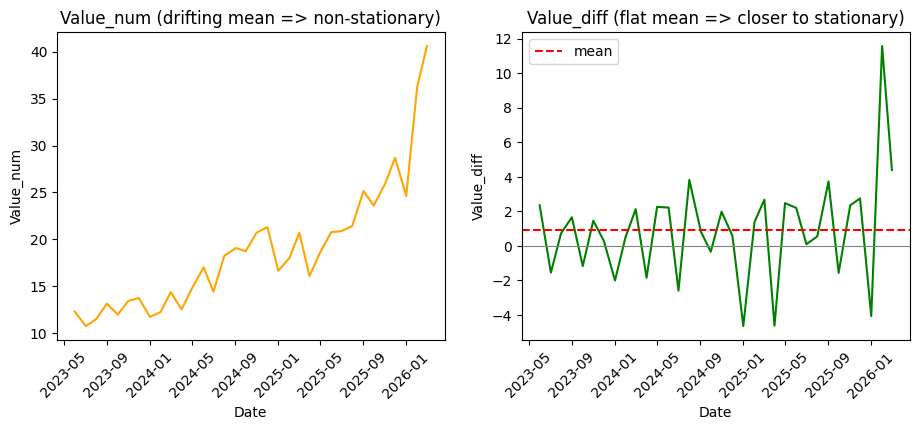

In [299]:
# How differencing removes trend: Value_num (trending) vs Value_diff (detrended)
## Value_diff = Value_num[t] - Value_num[t-1] => a linear trend cancels, leaving changes around a constant mean.

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(final.index, final['Value_num'], color='orange')
ax[0].set_title("Value_num (drifting mean => non-stationary)")
ax[0].set_xlabel("Date"); ax[0].set_ylabel("Value_num")
ax[0].tick_params(axis='x', rotation=45)

ax[1].plot(final.index, final['Value_diff'], color='green')
ax[1].axhline(final['Value_diff'].mean(), color='red', ls='--', label='mean') # roughly flat mean
ax[1].axhline(0, color='grey', lw=0.8)
ax[1].set_title("Value_diff (flat mean => closer to stationary)")
ax[1].set_xlabel("Date"); ax[1].set_ylabel("Value_diff")
ax[1].tick_params(axis='x', rotation=45); ax[1].legend()

#plt.tight_layout()
plt.show()

In [ ]:
#final.isnull().sum()
#final.head()
final.shape